In [ ]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('../..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.sparse.linalg import cg

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from scipy.optimize import curve_fit

'''
Fill in File Path
'''

heightOrSep = True # True if height, False if separation
sweep_values = [1,3,5,7,9,11,13,15]
# sweep_values = [11,14,17,20,23,26,29,32,35,40,45,50,55,60]

heights = []
separations = []
ejs = []
ecs = []
for sweep_value in sweep_values:
    file_path = f'../allplots/sepsweep3/sep{sweep_value}/results.pkl'
    with open(file_path, 'rb') as f:
        pickled_obj = pickle.load(f)
    heights.append(pickled_obj["parameters"]["sidelenZ"])
    separations.append(pickled_obj["parameters"]["separation"])
    ejs.append(pickled_obj["E_J"])
    ecs.append(pickled_obj["E_C"])
    print(f"Finished Reading {sweep_value}")

ratios = [ejs[i]/ecs[i] for i in range(len(ejs))]

Finished Reading 1
Finished Reading 3
Finished Reading 5
Finished Reading 7
Finished Reading 9
Finished Reading 11
Finished Reading 13
Finished Reading 15


In [76]:
# Generate raw LaTeX table for sweep runs
# Columns:
# Height & E_J/E_C & E_J & E_C & Degrees of Freedom & Integrated Volume Error & Grid dimensions (x, y, z)

import numpy as np
import pickle

# Use same sweep_values defined above
rows = []

for sweep_value in sweep_values:
    file_path = f'../allplots/sepsweep3/sep{sweep_value}/results.pkl'
    with open(file_path, 'rb') as f:
        pickled_obj = pickle.load(f)

    params = pickled_obj.get("parameters", {})
    ej = float(pickled_obj.get("E_J", np.nan))
    ec = float(pickled_obj.get("E_C", np.nan))
    ratio = ej / ec if np.isfinite(ej) and np.isfinite(ec) and ec != 0 else np.nan

    # Height
    height = params.get("sidelenZ", sweep_value)

    # Degrees of freedom: try direct key first, then femsystem object
    dofs = pickled_obj.get("dofs", None)
    if dofs is None:
        femsystem_obj = pickled_obj.get("femsystem", None)
        dofs = getattr(femsystem_obj, "dofs", np.nan)

    # Integrated volume error (%): compare integrated_volume vs geometric volume if available
    integrated_volume = pickled_obj.get("integrated_volume", np.nan)
    if np.isfinite(integrated_volume):
        if "volume" in params:
            true_volume = float(params["volume"])
        else:
            true_volume = float(params.get("sidelenX", np.nan)) * float(params.get("sidelenY", np.nan)) * float(params.get("sidelenZ", np.nan)) * 2.0
        vol_err_pct = ((integrated_volume - true_volume) / true_volume) * 100.0 if np.isfinite(true_volume) and true_volume != 0 else np.nan
    else:
        vol_err_pct = np.nan

    grid_x = params.get("gridlenX", np.nan)
    grid_y = params.get("gridlenY", np.nan)
    grid_z = params.get("gridlenZ", np.nan)

    rows.append({
        "sep": sweep_value,
        "ratio": ratio,
        "ej": ej,
        "ec": ec,
        "dofs": dofs,
        "vol_err_pct": vol_err_pct,
        "grid": (grid_x, grid_y, grid_z),
    })

# Sort by height for cleaner presentation
rows = sorted(rows, key=lambda r: float(r["sep"]))

# Build LaTeX
row_end = r"\\"
latex_lines = []
latex_lines.append("\\begin{tabular}{r r r r r r l}")
latex_lines.append("\\hline")
latex_lines.append(
    "Separation & $E_J/E_C$ & $E_J$ & $E_C$ & Degrees of Freedom & Integrated Volume Error (\\%) & Grid dimensions $(x,y,z)$ "
    + row_end
)
latex_lines.append("\\hline")

for r in rows:
    h = f"{float(r['sep']):.6g}" if np.isfinite(r["sep"]) else "nan"
    ratio = f"{r['ratio']:.6g}" if np.isfinite(r["ratio"]) else "nan"
    ej = f"{r['ej']:.6g}" if np.isfinite(r["ej"]) else "nan"
    ec = f"{r['ec']:.6g}" if np.isfinite(r["ec"]) else "nan"
    dofs = f"{int(r['dofs'])}" if np.isfinite(r["dofs"]) else "nan"
    verr = f"{r['vol_err_pct']:.6g}" if np.isfinite(r["vol_err_pct"]) else "nan"
    gx, gy, gz = r["grid"]
    gxs = f"{gx:.6g}" if np.isfinite(gx) else "nan"
    gys = f"{gy:.6g}" if np.isfinite(gy) else "nan"
    gzs = f"{gz:.6g}" if np.isfinite(gz) else "nan"
    grid_s = f"({gxs}, {gys}, {gzs})"

    latex_lines.append(f"{h} & {ratio} & {ej} & {ec} & {dofs} & {verr} & {grid_s} " + row_end)

latex_lines.append("\\hline")
latex_lines.append("\\end{tabular}")

latex_table = "\n".join(latex_lines)
print(latex_table)

# If you want to paste directly into Overleaf, copy latex_table.

\begin{tabular}{r r r r r r l}
\hline
Separation & $E_J/E_C$ & $E_J$ & $E_C$ & Degrees of Freedom & Integrated Volume Error (\%) & Grid dimensions $(x,y,z)$ \\
\hline
1 & 2.88212 & 6.04578 & 2.09769 & 47212 & 0.185645 & (51, 60, 60) \\
3 & 1.37525 & 3.24062 & 2.35638 & 51975 & 0.249304 & (53, 60, 60) \\
5 & 0.762871 & 1.97416 & 2.58781 & 56560 & 0.290375 & (55, 60, 60) \\
7 & 0.489428 & 1.36636 & 2.79175 & 60415 & 0.247083 & (57, 60, 60) \\
9 & 0.446567 & 1.32393 & 2.96469 & 63362 & 0.286395 & (59, 60, 60) \\
11 & 0.392999 & 1.22288 & 3.11166 & 67923 & 0.270776 & (61, 60, 60) \\
13 & 0.355177 & 1.14863 & 3.23395 & 72020 & 0.185077 & (63, 60, 60) \\
15 & 0.377627 & 1.25983 & 3.33619 & 73429 & 0.1677 & (65, 60, 60) \\
\hline
\end{tabular}


In [65]:
latex_table = []
latex_table.append("\\begin{tabular}{|c|c|c|c|c|c|c|}")
latex_table.append("\\hline")
latex_table.append("Height & $E_J/E_C$ & $E_J$ & $E_C$ & Degrees of Freedom & Integrated Volume Error & Grid dimensions (x, y, z) \\\\")
latex_table.append("\\hline")

for sweep_value in sweep_values:
    file_path = f'../allplots/heightsweep4/height{sweep_value}/results.pkl'
    with open(file_path, 'rb') as f:
        pickled_obj = pickle.load(f)
    height = pickled_obj["parameters"]["sidelenZ"]
    separation = pickled_obj["parameters"]["separation"]
    ej = pickled_obj["E_J"]
    ec = pickled_obj["E_C"]
    ratio = ej/ec
    dof = pickled_obj.get("dofs", "N/A")
    # Try to get error and grid dims, put N/A if missing
    volume_error = pickled_obj.get("integrated_volume_error", "N/A")
    grid_dims = pickled_obj.get("grid_shape", pickled_obj["parameters"].get("shape", "N/A"))
    # Grid dims should be in (x,y,z) or [x,y,z] format
    dims_str = "N/A"
    if isinstance(grid_dims, (list, tuple)) and len(grid_dims)==3:
        dims_str = f"{grid_dims[0]} {grid_dims[1]} {grid_dims[2]}"
    elif isinstance(grid_dims, str):
        dims_str = grid_dims
    else:
        dims_str = str(grid_dims)
    latex_table.append(
        f"{height} & {ratio:.6g} & {ej:.6g} & {ec:.6g} & {dof} & {volume_error} & {dims_str} \\\\"
    )
    latex_table.append("\\hline")

latex_table.append("\\end{tabular}")

# Optionally print or write to file:
raw_latex = "\n".join(latex_table)
print(raw_latex)

FileNotFoundError: [Errno 2] No such file or directory: '../allplots/heightsweep4/height1/results.pkl'

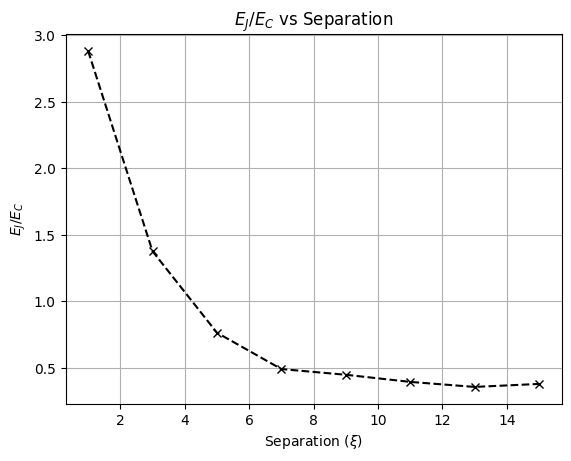

In [72]:
plt.plot(separations,ratios,"x--",color="black")
plt.xlabel("Separation ($\\xi$)")
plt.ylabel("$E_J/E_C$")
plt.title("$E_J/E_C$ vs Separation")
plt.grid(True)
# plt.legend()
plt.show()

Degree of Polynomial Fit: 1.857438611266565 $\pm$ 0.06212865007821848


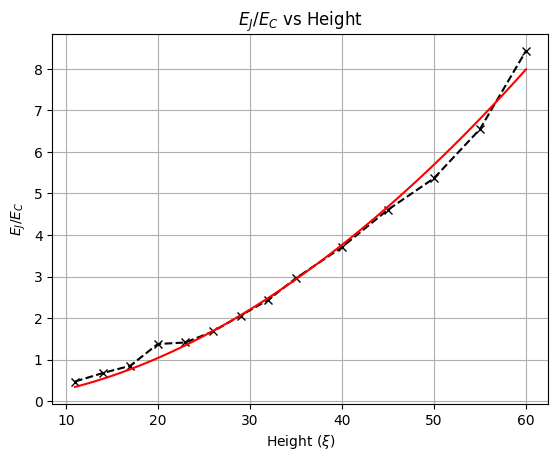

In [63]:
def fit_curve(heights, ratios):
    # Define the function to fit
    def func(x, a, n):
        return a * (x**n)

    # Initial guess for the parameters
    initial_guess = [1, 1]

    # Perform the fit and get covariance
    popt, pcov = curve_fit(func, heights, ratios, p0=initial_guess)

    # Calculate standard errors from the covariance matrix diagonal
    perr = np.sqrt(np.diag(pcov))

    # Return both parameters and their standard errors (in order)
    return popt, perr

# heights = [10,20,30,40,50]
# ratios = [0.033529601991176605,0.045130349695682526,0.09219560027122498,0.12259875237941742,0.18245354294776917]

popt, perr = fit_curve(heights,ratios)
xs = jnp.linspace(min(heights),max(heights),100)
ys = popt[0] * xs**popt[1]
print(f"Degree of Polynomial Fit: {popt[1]} $\pm$ {perr[1]}")


plt.plot(heights,ratios,"x--",color="black")
plt.plot(xs,ys,"-",color="red",label=f"Curve Fit y = {popt[0]:.4g}x^{popt[1]:.4g}")
plt.xlabel("Height ($\\xi$)")
plt.ylabel("$E_J/E_C$")
plt.title("$E_J/E_C$ vs Height")
plt.grid(True)
# plt.legend()
plt.show()